# Patient vs Healthy Evaluation with Frozen BS-JEPA Embeddings

Dataset: `/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/moodlearning`

Goal: evaluate whether a pretrained BS-JEPA model can classify patients vs healthy controls on the moodlearning dataset.

Comparison: frozen pretrained BS-JEPA subject embeddings versus simple machine learning baselines built from raw FC upper-triangle features.

Evaluation protocol: stratified cross-validation for model comparison, plus a stratified held-out test split for interpretable confusion matrices and classification reports. All scalers, PCA steps, and classifiers are fit only inside training folds or the training split to avoid leakage.

Main analysis uses the pretrained encoder as a frozen feature extractor. Fine-tuning the encoder is intentionally out of scope here and listed only as an optional extension at the end.

In [46]:
from __future__ import annotations

from pathlib import Path
import json
import pickle
import warnings
from collections import Counter, defaultdict
from typing import Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    sns = None
    HAS_SEABORN = False

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from torch.utils.data import Dataset
from torch_geometric.data import Data

from bsjepa.data import BrainGraphDataset, load_atlas, build_graph, pearson_correlation
from bsjepa.model import build_bsjepa
from bsjepa.evaluation import extract_subject_embeddings, normalize_subject_id, LabeledGraphDataset

# -----------------------------
# Manual configuration
# -----------------------------
DATA_DIR = Path("/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/moodlearning")
REPO_ROOT = Path.cwd()

# Leave as None to infer. For this dataset, moodlearning_merged.pkl is detected automatically.
DATA_FILE = None

# Set this to a final artifact .pt, checkpoint .pt, model_metadata.json, or artifact directory.
# If None, the notebook searches outputs/ and picks the newest candidate.
ARTIFACT_OR_CHECKPOINT_PATH = '/Users/stefanovannoni/Downloads/checkpoint_0009.pt'

# Set manually if atlas inference fails. The atlas must match the pretrained model and graph region order.
ATLAS_CSV = None

# Set manually if label inference is wrong or ambiguous. For moodlearning_merged.pkl this should be "diagnosis".
LABEL_COLUMN = None
LABEL_KEY_CANDIDATES = ["label", "group", "diagnosis", "condition", "class", "target", "patient", "is_patient"]

# This dataset was inspected as diagnosis values pz/nc. Keep these editable for other datasets.
PATIENT_VALUES = {"patient", "patients", "case", "cases", "mdd", "clinical", "pz", "1", 1, True}
HEALTHY_VALUES = {"healthy", "control", "controls", "hc", "nc", "0", 0, False}

RANDOM_SEED = 42
N_SPLITS = 5
TEST_SIZE = 0.20
BATCH_SIZE = 32

# Graph options. These should match the pretrained model/data configuration whenever possible.
NODE_FEATURES = "bold"       # "bold", "fc_row", or "ones"
BOLD_KEY = "BOLD"
FC_KEY = "FC"
TRANSPOSE_BOLD = False
GRAPH_STRATEGY = "positive_proportional"
TOP_K = 8
THRESHOLD = 0.20

# Compatibility setting for passthrough-BOLD checkpoints.
# This checkpoint expects 190 node features, so use one 190-timepoint BOLD window
# as graph.x while keeping FC/graph construction based on the full BOLD signal.
BOLD_WINDOW_SIZE = 190
BOLD_WINDOW_START = 0

# Raw FC features can be very high-dimensional; auto adds PCA inside training folds when p >> n.
USE_RAW_PCA = "auto"
RAW_PCA_VARIANCE = 0.95

OUTPUT_DIR = REPO_ROOT / "outputs" / "patient_vs_healthy_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"repo={REPO_ROOT}")
print(f"data_dir={DATA_DIR}")
print(f"output_dir={OUTPUT_DIR}")
print(f"device={DEVICE}")

repo=/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Code/bs_jepa
data_dir=/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/moodlearning
output_dir=/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Code/bs_jepa/outputs/patient_vs_healthy_evaluation
device=mps


## Dataset Inspection

This section lists files and previews structure without dumping large arrays. The current dataset is expected to contain pickle dictionaries, but the helper functions below also support `.pt`, `.npz`, `.csv`, `.tsv`, and `.xlsx` sources.

In [47]:
def summarize_object(obj: Any, max_depth: int = 2, _depth: int = 0, max_items: int = 5) -> str:
    """Return a compact structural summary without printing large arrays."""
    indent = "  " * _depth
    if isinstance(obj, dict):
        keys = list(obj.keys())
        lines = [f"{indent}dict(len={len(obj)}, keys={keys[:max_items]!r})"]
        if _depth < max_depth:
            for key in keys[:max_items]:
                lines.append(f"{indent}  {key!r}:")
                lines.append(summarize_object(obj[key], max_depth, _depth + 2, max_items))
        return "\n".join(lines)
    if isinstance(obj, (list, tuple)):
        lines = [f"{indent}{type(obj).__name__}(len={len(obj)})"]
        if obj and _depth < max_depth:
            lines.append(summarize_object(obj[0], max_depth, _depth + 1, max_items))
        return "\n".join(lines)
    if isinstance(obj, np.ndarray):
        return f"{indent}ndarray(shape={obj.shape}, dtype={obj.dtype})"
    if torch.is_tensor(obj):
        return f"{indent}tensor(shape={tuple(obj.shape)}, dtype={obj.dtype})"
    if isinstance(obj, pd.DataFrame):
        return f"{indent}DataFrame(shape={obj.shape}, columns={list(obj.columns)[:max_items]!r})"
    return f"{indent}{type(obj).__name__}: {repr(obj)[:160]}"


def load_file_preview(path: Path) -> Any:
    if path.suffix == ".pkl":
        with path.open("rb") as handle:
            return pickle.load(handle)
    if path.suffix == ".pt":
        return torch.load(path, map_location="cpu", weights_only=False)
    if path.suffix == ".npz":
        archive = np.load(path, allow_pickle=True)
        return {key: archive[key] for key in archive.files}
    if path.suffix == ".csv":
        return pd.read_csv(path)
    if path.suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    if path.suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported preview type: {path}")

supported_suffixes = {".pkl", ".pt", ".npz", ".csv", ".tsv", ".xlsx", ".xls"}
all_files = [path for path in DATA_DIR.rglob("*") if path.is_file()]
relevant_files = [path for path in all_files if path.suffix.lower() in supported_suffixes]
counts = Counter(path.suffix.lower() for path in relevant_files)

print(f"Found {len(all_files)} total files under {DATA_DIR}")
print("Supported files by suffix:", dict(counts))
for path in relevant_files[:50]:
    print(" -", path.relative_to(DATA_DIR))

likely_metadata = [p for p in relevant_files if p.suffix.lower() in {".csv", ".tsv", ".xlsx", ".xls"}]
likely_imaging = [p for p in relevant_files if p.suffix.lower() in {".pkl", ".pt", ".npz"}]
print(f"likely_metadata_files={len(likely_metadata)}")
print(f"likely_imaging_files={len(likely_imaging)}")

for path in relevant_files[:6]:
    print("\n====", path.relative_to(DATA_DIR))
    try:
        obj = load_file_preview(path)
        print(summarize_object(obj, max_depth=2, max_items=5))
        if isinstance(obj, pd.DataFrame):
            display(obj.head())
    except Exception as exc:
        warnings.warn(f"Could not inspect {path}: {exc}")

Found 3 total files under /Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/moodlearning
Supported files by suffix: {'.pkl': 3}
 - moodlearning_merged.pkl
 - moodlearning_pz.pkl
 - moodlearning_cont.pkl
likely_metadata_files=0
likely_imaging_files=3

==== moodlearning_merged.pkl
dict(len=62, keys=['MLPO052', 'MLPO053', 'MLPO059', 'MLPO066', 'MLPO072'])
  'MLPO052':
    dict(len=5, keys=['BOLD', 'FC', 'sex', 'age', 'diagnosis'])
  'MLPO053':
    dict(len=5, keys=['BOLD', 'FC', 'sex', 'age', 'diagnosis'])
  'MLPO059':
    dict(len=5, keys=['BOLD', 'FC', 'sex', 'age', 'diagnosis'])
  'MLPO066':
    dict(len=5, keys=['BOLD', 'FC', 'sex', 'age', 'diagnosis'])
  'MLPO072':
    dict(len=5, keys=['BOLD', 'FC', 'sex', 'age', 'diagnosis'])

==== moodlearning_pz.pkl
dict(len=33, keys=['MLPO001', 'MLPO011', 'MLPO012', 'MLPO014', 'MLPO019'])
  'MLPO001':
    dict(len=4, keys=['BOLD', 'FC', 'sex', 'age'])
  'MLPO011':
    dict(len=4, keys=['BOLD', 'FC', 'sex', 'age'])
  'MLPO012':
    dict(len=4, 

## Dataset Loading Helpers

The helpers normalize subject records to `subject_id`, binary `label` where `1 = patient` and `0 = healthy`, imaging arrays (`BOLD` and/or `FC`), and optional metadata. If inference is ambiguous, set `DATA_FILE`, `LABEL_COLUMN`, `PATIENT_VALUES`, or `HEALTHY_VALUES` in the configuration cell.

In [48]:
def _norm_value(value: Any) -> str:
    return str(value).strip().lower()


def normalize_binary_label(value: Any) -> int | None:
    """Map configured patient/healthy values to 1/0."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    patient_norm = {_norm_value(v) for v in PATIENT_VALUES}
    healthy_norm = {_norm_value(v) for v in HEALTHY_VALUES}
    text = _norm_value(value)
    if text in patient_norm:
        return 1
    if text in healthy_norm:
        return 0
    return None


def find_label_column(metadata_df: pd.DataFrame | None) -> str | None:
    if LABEL_COLUMN is not None:
        if metadata_df is not None and LABEL_COLUMN not in metadata_df.columns:
            warnings.warn(f"Configured LABEL_COLUMN={LABEL_COLUMN!r} is not in metadata columns")
        return LABEL_COLUMN
    if metadata_df is None:
        return None
    lowered = {str(col).lower(): col for col in metadata_df.columns}
    for candidate in LABEL_KEY_CANDIDATES:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    for col in metadata_df.columns:
        mapped = metadata_df[col].map(normalize_binary_label)
        if mapped.notna().sum() >= 2 and mapped.nunique(dropna=True) == 2:
            return col
    return None


def find_record_label_key(records: list[dict[str, Any]]) -> str | None:
    if LABEL_COLUMN is not None:
        return LABEL_COLUMN
    all_keys = []
    for record in records[:20]:
        all_keys.extend(str(key) for key in record.keys())
    lowered = {key.lower(): key for key in all_keys}
    for candidate in LABEL_KEY_CANDIDATES:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    key_counts = Counter(all_keys)
    for key, _ in key_counts.most_common():
        values = [record.get(key) for record in records if isinstance(record, dict)]
        mapped = [normalize_binary_label(value) for value in values]
        mapped = [value for value in mapped if value is not None]
        if len(mapped) >= 2 and len(set(mapped)) == 2:
            return key
    return None


def load_tabular_file(path: Path) -> pd.DataFrame:
    if path.suffix == ".csv":
        return pd.read_csv(path)
    if path.suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    if path.suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported metadata file: {path}")


def load_metadata_table(data_dir: Path) -> tuple[pd.DataFrame | None, Path | None]:
    candidates = [p for p in data_dir.rglob("*") if p.suffix.lower() in {".csv", ".tsv", ".xlsx", ".xls"}]
    if not candidates:
        return None, None
    scored = []
    for path in candidates:
        name = path.name.lower()
        score = int("metadata" in name) + int("phenotype" in name) + int("label" in name) + int("subject" in name)
        scored.append((score, path))
    path = sorted(scored, key=lambda item: (item[0], item[1].stat().st_mtime), reverse=True)[0][1]
    return load_tabular_file(path), path


def load_object_file(path: Path) -> Any:
    if path.suffix == ".pkl":
        with path.open("rb") as handle:
            return pickle.load(handle)
    if path.suffix == ".pt":
        return torch.load(path, map_location="cpu", weights_only=False)
    if path.suffix == ".npz":
        archive = np.load(path, allow_pickle=True)
        return {key: archive[key] for key in archive.files}
    raise ValueError(f"Unsupported data file: {path}")


def record_has_imaging(record: Any) -> bool:
    if not isinstance(record, dict):
        return False
    keys = set(record.keys())
    return any(key in keys for key in [BOLD_KEY, FC_KEY, "BOLD", "FC", "time_series", "X", "fc_matrix"])


def infer_data_file(data_dir: Path) -> Path:
    if DATA_FILE is not None:
        path = Path(DATA_FILE)
        if not path.exists():
            raise FileNotFoundError(f"Configured DATA_FILE does not exist: {path}")
        return path
    candidates = [p for p in data_dir.rglob("*") if p.suffix.lower() in {".pkl", ".pt", ".npz"}]
    if not candidates:
        raise FileNotFoundError(f"No supported imaging data files found under {data_dir}")
    def score(path: Path) -> tuple[int, float]:
        name = path.name.lower()
        return (int("merged" in name) * 10 + int("all" in name) * 3, path.stat().st_mtime)
    return sorted(candidates, key=score, reverse=True)[0]


def subject_id_column(metadata_df: pd.DataFrame) -> str | None:
    candidates = ["subject", "subject_id", "id", "participant_id", "participant", "sub"]
    lowered = {str(col).lower(): col for col in metadata_df.columns}
    for candidate in candidates:
        if candidate in lowered:
            return lowered[candidate]
    return None


def load_subject_records(data_dir: Path) -> tuple[pd.DataFrame, Path, Path | None]:
    metadata_df, metadata_path = load_metadata_table(data_dir)
    data_path = infer_data_file(data_dir)
    obj = load_object_file(data_path)

    rows: list[dict[str, Any]] = []
    if isinstance(obj, dict) and all(record_has_imaging(value) for value in obj.values()):
        for subject_id, record in obj.items():
            rows.append({"subject_id": normalize_subject_id(subject_id), "record": record, "source_path": data_path})
    elif isinstance(obj, dict) and record_has_imaging(obj):
        subject_id = obj.get("subject_id", data_path.stem)
        rows.append({"subject_id": normalize_subject_id(subject_id), "record": obj, "source_path": data_path})
    elif isinstance(obj, list):
        for index, record in enumerate(obj):
            if not record_has_imaging(record):
                continue
            subject_id = record.get("subject_id", record.get("id", f"{data_path.stem}_{index}"))
            rows.append({"subject_id": normalize_subject_id(subject_id), "record": record, "source_path": data_path})
    elif data_path.suffix == ".npz" and record_has_imaging(obj):
        rows.append({"subject_id": normalize_subject_id(data_path.stem), "record": obj, "source_path": data_path})
    else:
        raise TypeError(f"Could not interpret {data_path} as subject imaging records")

    if not rows:
        raise ValueError(f"No usable subject imaging records found in {data_path}")

    records = [row["record"] for row in rows]
    record_label_key = find_record_label_key(records)

    metadata_by_id: dict[str, dict[str, Any]] = {}
    metadata_label_column = None
    if metadata_df is not None:
        id_col = subject_id_column(metadata_df)
        metadata_label_column = find_label_column(metadata_df)
        if id_col is not None:
            for _, row in metadata_df.iterrows():
                metadata_by_id[normalize_subject_id(row[id_col])] = row.to_dict()
        else:
            warnings.warn(f"Metadata file {metadata_path} has no obvious subject ID column; not joining it")

    for row in rows:
        record = row["record"]
        metadata = dict(metadata_by_id.get(row["subject_id"], {}))
        record_metadata = {key: value for key, value in record.items() if key not in {BOLD_KEY, FC_KEY, "BOLD", "FC", "time_series", "X", "fc_matrix"}}
        metadata = {**metadata, **record_metadata}
        label_raw = None
        if record_label_key is not None and record_label_key in record:
            label_raw = record.get(record_label_key)
        elif metadata_label_column is not None and metadata_label_column in metadata:
            label_raw = metadata.get(metadata_label_column)
        row["metadata"] = metadata
        row["label_raw"] = label_raw
        row["label"] = normalize_binary_label(label_raw)
        row["has_bold"] = any(key in record for key in [BOLD_KEY, "BOLD", "time_series", "X"])
        row["has_fc"] = any(key in record for key in [FC_KEY, "FC", "fc_matrix"])

    df = pd.DataFrame(rows)
    print(f"Selected data file: {data_path}")
    print(f"Metadata file: {metadata_path}")
    print(f"Inferred record label key: {record_label_key!r}")
    print(f"Inferred metadata label column: {metadata_label_column!r}")
    return df, data_path, metadata_path

In [49]:
records_df, DATA_SOURCE_FILE, METADATA_FILE = load_subject_records(DATA_DIR)

usable_df = records_df[records_df["label"].isin([0, 1]) & (records_df["has_bold"] | records_df["has_fc"])].copy()
missing_labels = int(records_df["label"].isna().sum())
missing_imaging = int((~(records_df["has_bold"] | records_df["has_fc"])).sum())

print(f"loaded_subjects={len(records_df)}")
print(f"subjects_with_labels={int(records_df['label'].notna().sum())}")
print(f"patient_count={int((usable_df['label'] == 1).sum())}")
print(f"healthy_count={int((usable_df['label'] == 0).sum())}")
print(f"missing_labels={missing_labels}")
print(f"missing_imaging={missing_imaging}")
print(f"final_usable_sample_size={len(usable_df)}")
print("raw label counts:", dict(Counter(records_df["label_raw"].map(str))))

display(usable_df[["subject_id", "label_raw", "label", "has_bold", "has_fc"]].head())

if len(usable_df) < 4:
    raise ValueError("Too few labeled subjects for patient-vs-healthy evaluation")
if usable_df["label"].nunique() != 2:
    raise ValueError("Usable labels are not binary. Update LABEL_COLUMN/PATIENT_VALUES/HEALTHY_VALUES.")

Selected data file: /Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/moodlearning/moodlearning_merged.pkl
Metadata file: None
Inferred record label key: 'diagnosis'
Inferred metadata label column: None
loaded_subjects=62
subjects_with_labels=62
patient_count=33
healthy_count=29
missing_labels=0
missing_imaging=0
final_usable_sample_size=62
raw label counts: {'nc': 29, 'pz': 33}


,subject_id,label_raw,label,has_bold,has_fc
0,MLPO052,nc,0,True,True
1,MLPO053,nc,0,True,True
2,MLPO059,nc,0,True,True
3,MLPO066,nc,0,True,True
4,MLPO072,nc,0,True,True


## Atlas and Graph Construction

The atlas must match the pretrained model and the region order in the dataset. If inference fails or picks the wrong file, set `ATLAS_CSV` manually in the configuration cell.

**BOLD upsampling note:** this notebook can resample moodlearning BOLD from 190 to 1190 time points so an HCP checkpoint trained with `bold + passthrough` can be loaded. This is a compatibility workaround: interpolation does not add temporal information. Treat these results as exploratory and compare them against the raw FC baselines.

In [50]:
def _existing_path(value: Any) -> Path | None:
    if value is None:
        return None
    path = Path(str(value)).expanduser()
    return path if path.exists() else None


def checkpoint_metadata_paths() -> list[Path]:
    roots = []
    if ARTIFACT_OR_CHECKPOINT_PATH is not None:
        p = Path(ARTIFACT_OR_CHECKPOINT_PATH).expanduser()
        roots.append(p if p.is_dir() else p.parent)
    roots.append(REPO_ROOT / "outputs")
    paths = []
    for root in roots:
        if root.exists():
            paths.extend(root.rglob("model_metadata.json"))
    return paths


def infer_atlas_csv() -> Path:
    configured = _existing_path(ATLAS_CSV)
    if configured is not None:
        return configured

    # Artifact metadata can preserve the training config path.
    for meta_path in checkpoint_metadata_paths():
        try:
            meta = json.loads(meta_path.read_text())
            candidate = _existing_path(meta.get("configuration", {}).get("data", {}).get("atlas_csv"))
            if candidate is not None:
                return candidate
        except Exception as exc:
            warnings.warn(f"Could not read artifact metadata {meta_path}: {exc}")

    # Repo config.yaml, if available.
    config_path = REPO_ROOT / "config.yaml"
    if config_path.exists():
        try:
            import yaml
            config = yaml.safe_load(config_path.read_text())
            candidate = _existing_path(config.get("data", {}).get("atlas_csv"))
            if candidate is not None:
                return candidate
        except Exception as exc:
            warnings.warn(f"Could not parse {config_path}: {exc}")

    search_roots = [DATA_DIR, REPO_ROOT]
    # A bounded parent search catches common sibling repos with atlas files.
    for parent in list(REPO_ROOT.parents)[:3]:
        search_roots.append(parent)

    seen = set()
    candidates: list[Path] = []
    for root in search_roots:
        if not root.exists() or root in seen:
            continue
        seen.add(root)
        try:
            for path in root.rglob("*.csv"):
                name = path.name.lower()
                if any(token in name for token in ["atlas", "rsn", "glasser"]):
                    candidates.append(path)
        except PermissionError:
            continue

    if candidates:
        def atlas_score(path: Path) -> tuple[int, float]:
            name = path.name.lower()
            return (
                int("glasser379" in name) * 20 + int("rsn" in name) * 10 + int("atlas" in name) * 5,
                path.stat().st_mtime,
            )
        return sorted(candidates, key=atlas_score, reverse=True)[0]

    raise FileNotFoundError(
        "Could not infer an atlas CSV. Set ATLAS_CSV in the configuration cell. "
        "The file must contain rsn_id and rsn_name columns and match the model region order."
    )

ATLAS_PATH = infer_atlas_csv()
atlas = load_atlas(ATLAS_PATH)
print(f"atlas_csv={ATLAS_PATH}")
print(f"atlas_regions={atlas.num_regions} atlas_rsns={atlas.num_rsns}")

atlas_csv=/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Code/brain_subnetwork_jepa_v2/data/atlas/glasser379_to_rsn12.csv
atlas_regions=379 atlas_rsns=12


In [51]:
def zscore_regions(bold: torch.Tensor) -> torch.Tensor:
    return (bold - bold.mean(dim=1, keepdim=True)) / bold.std(dim=1, keepdim=True, unbiased=False).clamp_min(1e-8)


def select_bold_window(bold: torch.Tensor, window_size: int | None, window_start: int) -> torch.Tensor:
    """Select node-feature BOLD window without changing the full-signal FC graph."""
    if window_size is None:
        return bold
    if window_size < 1:
        raise ValueError("BOLD_WINDOW_SIZE must be positive or None")
    if window_start < 0:
        raise ValueError("BOLD_WINDOW_START must be non-negative")
    window_end = window_start + window_size
    if window_end > bold.shape[1]:
        raise ValueError(
            f"Requested BOLD window [{window_start}, {window_end}) but subject has "
            f"only {bold.shape[1]} time points"
        )
    return bold[:, window_start:window_end]


def get_record_array(record: dict[str, Any], keys: list[str]) -> Any | None:
    for key in keys:
        if key in record:
            return record[key]
    return None


def make_graph_from_record(record: dict[str, Any], atlas) -> Data:
    bold_value = get_record_array(record, [BOLD_KEY, "BOLD", "time_series", "X"])
    fc_value = get_record_array(record, [FC_KEY, "FC", "fc_matrix"])

    bold = None if bold_value is None else torch.as_tensor(bold_value, dtype=torch.float32)
    if bold is not None and TRANSPOSE_BOLD:
        bold = bold.T
    if bold is not None and bold.ndim != 2:
        raise ValueError(f"BOLD must be 2D region-by-time; got shape={tuple(bold.shape)}")
    if bold is not None and bold.shape[0] != atlas.num_regions:
        raise ValueError(f"BOLD has {bold.shape[0]} regions but atlas has {atlas.num_regions}")

    if fc_value is None:
        if bold is None:
            raise KeyError("Subject contains neither BOLD nor FC data")
        fc = pearson_correlation(zscore_regions(bold))
    else:
        fc = torch.as_tensor(fc_value, dtype=torch.float32)
    if fc.ndim != 2 or fc.shape[0] != fc.shape[1]:
        raise ValueError(f"FC must be square; got shape={tuple(fc.shape)}")
    if fc.shape[0] != atlas.num_regions:
        raise ValueError(f"FC has {fc.shape[0]} regions but atlas has {atlas.num_regions}")

    graph = build_graph(fc, strategy=GRAPH_STRATEGY, top_k=TOP_K, threshold=THRESHOLD)
    if NODE_FEATURES == "bold":
        if bold is None:
            raise KeyError("NODE_FEATURES='bold' requires BOLD data")
        graph.x = zscore_regions(select_bold_window(bold, BOLD_WINDOW_SIZE, BOLD_WINDOW_START))
    elif NODE_FEATURES == "fc_row":
        graph.x = fc.float()
    elif NODE_FEATURES == "ones":
        graph.x = torch.ones(fc.shape[0], 1, dtype=torch.float32)
    else:
        raise ValueError(f"Unsupported NODE_FEATURES={NODE_FEATURES!r}")
    graph.rsn_ids = atlas.rsn_ids.clone()
    graph.region_ids = torch.arange(atlas.num_regions)
    return graph


class InMemoryGraphDataset(Dataset):
    def __init__(self, rows: pd.DataFrame, atlas) -> None:
        self.rows = rows.reset_index(drop=True).copy()
        self.atlas = atlas
        self._graphs = [make_graph_from_record(row["record"], atlas) for _, row in self.rows.iterrows()]

    def __len__(self) -> int:
        return len(self._graphs)

    def __getitem__(self, index: int) -> Data:
        return self._graphs[index]

    @property
    def subject_ids(self) -> list[str]:
        return self.rows["subject_id"].tolist()

    def get_subject_metadata(self, index: int) -> dict[str, Any]:
        return self.rows.iloc[index]["metadata"]


def build_compatible_graph_dataset(rows: pd.DataFrame, atlas):
    """Use BrainGraphDataset when possible; fallback to the same graph logic in memory."""
    if BOLD_WINDOW_SIZE is not None and NODE_FEATURES == "bold":
        manual_dataset = InMemoryGraphDataset(rows, atlas)
        return manual_dataset, list(range(len(manual_dataset)))
    try:
        base_dataset = BrainGraphDataset(
            DATA_SOURCE_FILE,
            atlas,
            node_features=NODE_FEATURES,
            bold_key=BOLD_KEY,
            fc_key=FC_KEY,
            transpose_bold=TRANSPOSE_BOLD,
            bold_window_size=BOLD_WINDOW_SIZE,
            bold_window_start=BOLD_WINDOW_START,
            graph_strategy=GRAPH_STRATEGY,
            top_k=TOP_K,
            threshold=THRESHOLD,
        )
        lookup = {normalize_subject_id(subject_id): idx for idx, subject_id in enumerate(base_dataset.subject_ids)}
        indices = [lookup[subject_id] for subject_id in rows["subject_id"]]
        # Validate a sample graph now, so later failures are not silent.
        _ = base_dataset[indices[0]]
        return base_dataset, indices
    except Exception as exc:
        warnings.warn(f"Falling back to in-memory graph construction instead of BrainGraphDataset: {exc}")
        manual_dataset = InMemoryGraphDataset(rows, atlas)
        return manual_dataset, list(range(len(manual_dataset)))

base_graph_dataset, graph_indices = build_compatible_graph_dataset(usable_df, atlas)
labels = usable_df["label"].astype(int).tolist()
subject_ids = usable_df["subject_id"].tolist()
labeled_graph_dataset = LabeledGraphDataset(base_graph_dataset, graph_indices, labels, subject_ids, label_dtype=torch.long)

graphs = [labeled_graph_dataset[i][0] for i in range(len(labeled_graph_dataset))]
node_counts = [int(graph.num_nodes) for graph in graphs]
feature_dims = [int(graph.x.shape[1]) for graph in graphs]
edge_counts = [int(graph.edge_index.shape[1]) for graph in graphs]
bold_time_lengths = [int(graph.x.shape[1]) for graph in graphs] if NODE_FEATURES == "bold" else []

print(f"graph_dataset={type(base_graph_dataset).__name__}")
print(f"n_graphs={len(graphs)}")
print(f"node_count_values={sorted(set(node_counts))}")
print(f"feature_dim_values={sorted(set(feature_dims))}")
if NODE_FEATURES == "bold":
    print(f"bold_time_length_values_after_optional_windowing={sorted(set(bold_time_lengths))}")
    print(f"BOLD_WINDOW_SIZE={BOLD_WINDOW_SIZE}")
    print(f"BOLD_WINDOW_START={BOLD_WINDOW_START}")
print(f"edge_count_min_median_max={(min(edge_counts), int(np.median(edge_counts)), max(edge_counts))}")
print(f"label_counts={dict(Counter(labels))}")

if len(set(node_counts)) != 1:
    raise ValueError("Not all graphs have matching node counts")
if len(set(feature_dims)) != 1:
    raise ValueError("Not all graphs have matching feature dimensions")
if node_counts[0] != atlas.num_regions:
    raise ValueError("Graph node count does not match atlas region count")

graph_dataset=InMemoryGraphDataset
n_graphs=62
node_count_values=[379]
feature_dim_values=[190]
bold_time_length_values_after_optional_windowing=[190]
BOLD_WINDOW_SIZE=190
BOLD_WINDOW_START=0
edge_count_min_median_max=(14158, 15674, 20002)
label_counts={0: 29, 1: 33}


## Pretrained Model Loading

Set `ARTIFACT_OR_CHECKPOINT_PATH` if automatic search does not find the intended model. The loader supports final artifact directories, `model_metadata.json`, artifact `*_final.pt` files, regular checkpoints, and raw state dicts when enough reconstruction information is available.

In [52]:
def find_checkpoint_candidates() -> list[Path]:
    candidates: list[Path] = []
    if ARTIFACT_OR_CHECKPOINT_PATH is not None:
        path = Path(ARTIFACT_OR_CHECKPOINT_PATH).expanduser()
        if not path.exists():
            raise FileNotFoundError(f"Configured artifact/checkpoint path does not exist: {path}")
        return [path]

    outputs = REPO_ROOT / "outputs"
    if outputs.exists():
        # Prefer final artifacts that have metadata nearby.
        for meta in outputs.rglob("model_metadata.json"):
            try:
                metadata = json.loads(meta.read_text())
                model_file = metadata.get("model_filename")
                if model_file and (meta.parent / model_file).exists():
                    candidates.append(meta.parent / model_file)
            except Exception as exc:
                warnings.warn(f"Could not parse {meta}: {exc}")
        candidates.extend(outputs.rglob("*_final.pt"))
        candidates.extend(outputs.rglob("checkpoint_*.pt"))
        candidates.extend(outputs.rglob("*.pt"))

    unique = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)
    return unique


def resolve_checkpoint_path(path: Path) -> Path:
    path = Path(path).expanduser()
    if path.is_file() and path.name == "model_metadata.json":
        metadata = json.loads(path.read_text())
        model_file = metadata.get("model_filename")
        if not model_file:
            raise KeyError(f"model_metadata.json has no model_filename: {path}")
        return path.parent / model_file
    if path.is_dir():
        meta = path / "model_metadata.json"
        if meta.exists():
            metadata = json.loads(meta.read_text())
            model_file = metadata.get("model_filename")
            if model_file and (path / model_file).exists():
                return path / model_file
        pts = sorted(path.glob("*.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
        if not pts:
            raise FileNotFoundError(f"No .pt checkpoint found in {path}")
        return pts[0]
    return path


def load_torch_checkpoint(path: Path, device: torch.device) -> Any:
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def strip_module_prefix(state_dict: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    if all(key.startswith("module.") for key in state_dict):
        return {key[len("module."):]: value for key, value in state_dict.items()}
    return state_dict


def read_adjacent_metadata(checkpoint_path: Path) -> dict[str, Any] | None:
    """Read model_metadata.json from an artifact directory, if present."""
    for meta_path in [checkpoint_path.parent / "model_metadata.json", checkpoint_path / "model_metadata.json"]:
        if meta_path.exists() and meta_path.is_file():
            try:
                return json.loads(meta_path.read_text())
            except Exception as exc:
                warnings.warn(f"Could not parse {meta_path}: {exc}")
    return None


def load_repo_config() -> dict[str, Any] | None:
    """Fallback for older checkpoint_*.pt files that do not save model_config."""
    config_path = REPO_ROOT / "config.yaml"
    if not config_path.exists():
        return None
    try:
        import yaml
        return yaml.safe_load(config_path.read_text())
    except Exception as exc:
        warnings.warn(f"Could not parse fallback config.yaml at {config_path}: {exc}")
        return None


def infer_input_dim_from_state_dict(state_dict: dict[str, torch.Tensor]) -> int | None:
    """Infer encoder input feature dimension from old checkpoints without reconstruction metadata."""
    for key in [
        "context_encoder.input_projection.weight",
        "target_encoder.input_projection.weight",
    ]:
        value = state_dict.get(key)
        if torch.is_tensor(value) and value.ndim == 2:
            return int(value.shape[1])
    return None


def infer_model_config_and_reconstruction(
    checkpoint: Any,
    checkpoint_path: Path,
    sample_graph: Data,
    state_dict: dict[str, torch.Tensor],
) -> tuple[dict[str, Any], dict[str, Any], str]:
    """Return model config and reconstruction info from artifact, metadata, config.yaml, and state dict."""
    reconstruction = checkpoint.get("reconstruction", {}) if isinstance(checkpoint, dict) else {}
    model_config = checkpoint.get("model_config", reconstruction.get("model_config")) if isinstance(checkpoint, dict) else None
    source = "checkpoint"

    if model_config is None:
        metadata = read_adjacent_metadata(checkpoint_path)
        if metadata is not None:
            model_config = metadata.get("architecture") or metadata.get("configuration", {}).get("model")
            reconstruction = reconstruction or metadata.get("reconstruction", {})
            source = "model_metadata.json"

    if model_config is None:
        repo_config = load_repo_config()
        if repo_config is not None and "model" in repo_config:
            model_config = dict(repo_config["model"])
            source = "repo config.yaml fallback"
            warnings.warn(
                "This checkpoint does not contain architecture metadata. Falling back to config.yaml. "
                "This is valid only if config.yaml still matches the run that produced the checkpoint. "
                "For future runs, prefer the exported final artifact directory containing model_metadata.json."
            )

    if model_config is None:
        raise KeyError(
            "Checkpoint does not contain model_config/reconstruction, and no usable model_metadata.json "
            "or config.yaml fallback was found. Set ARTIFACT_OR_CHECKPOINT_PATH to the final artifact "
            "directory or *_final.pt file, or rerun/export training with save_final_artifact enabled."
        )

    reconstruction = dict(reconstruction or {})
    state_input_dim = infer_input_dim_from_state_dict(state_dict)
    if "in_channels" not in reconstruction and "input_feature_dim" not in reconstruction and state_input_dim is not None:
        reconstruction["in_channels"] = state_input_dim
        source = f"{source} + state_dict input dimension"
    reconstruction.setdefault("in_channels", int(sample_graph.x.shape[1]))
    reconstruction.setdefault("num_regions", int(sample_graph.num_nodes))
    reconstruction.setdefault("model_config", model_config)
    return dict(model_config), reconstruction, source


def load_bsjepa_from_artifact(path: Path, sample_graph: Data, device: torch.device):
    checkpoint_path = resolve_checkpoint_path(path)
    checkpoint = load_torch_checkpoint(checkpoint_path, device)

    if isinstance(checkpoint, dict) and "model" in checkpoint:
        state_dict = checkpoint["model"]
    elif isinstance(checkpoint, dict) and all(torch.is_tensor(v) for v in checkpoint.values()):
        state_dict = checkpoint
    else:
        raise TypeError(f"Could not find a model state dict in {checkpoint_path}")
    state_dict = strip_module_prefix(state_dict)

    model_config, reconstruction, config_source = infer_model_config_and_reconstruction(
        checkpoint,
        checkpoint_path,
        sample_graph,
        state_dict,
    )

    expected_in_channels = int(reconstruction.get("in_channels", sample_graph.x.shape[1]))
    num_regions = int(reconstruction.get("num_regions", sample_graph.num_nodes))
    actual_in_channels = int(sample_graph.x.shape[1])
    feature_mode = str(model_config.get("feature_mode", "passthrough"))

    if num_regions != int(sample_graph.num_nodes):
        raise ValueError(f"Checkpoint expects {num_regions} regions but sample graph has {sample_graph.num_nodes}")
    if feature_mode != "conv1d" and expected_in_channels != actual_in_channels:
        raise ValueError(
            f"Feature dimension mismatch: checkpoint expects {expected_in_channels} node features, "
            f"but the moodlearning graphs provide {actual_in_channels}. "
            "This usually means the checkpoint was trained with passthrough BOLD using a different "
            "number of time points than the current graph.x. A frozen passthrough-BOLD encoder cannot "
            "directly consume a different time dimension. Set BOLD_WINDOW_SIZE to the checkpoint's "
            "expected input dimension when the downstream BOLD signal is long enough, use a compatible "
            "checkpoint trained with the same node feature dimension, train/export a model with "
            "model.feature_mode='conv1d', or train with data.node_features='fc_row' so the input "
            "dimension is atlas-region based."
        )

    model = build_bsjepa(in_channels=expected_in_channels, num_regions=num_regions, **model_config)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        warnings.warn(f"State-dict load had missing={missing[:5]} unexpected={unexpected[:5]}")
    model.to(device)
    model.eval()

    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    print(f"checkpoint_path={checkpoint_path}")
    print(f"architecture_source={config_source}")
    print(f"model_config={model_config}")
    print(f"expected_input_feature_dim={expected_in_channels}")
    print(f"actual_input_feature_dim={actual_in_channels}")
    print(f"parameters={parameter_count:,}")
    return model, checkpoint_path, checkpoint

candidates = find_checkpoint_candidates()
if not candidates:
    raise FileNotFoundError(
        "No pretrained BS-JEPA checkpoint/artifact found. Set ARTIFACT_OR_CHECKPOINT_PATH in the configuration cell."
    )

print("Checkpoint/artifact candidates, newest first:")
for candidate in candidates[:10]:
    print(" -", candidate)

model, CHECKPOINT_PATH, CHECKPOINT = load_bsjepa_from_artifact(candidates[0], graphs[0], DEVICE)

Checkpoint/artifact candidates, newest first:
 - /Users/stefanovannoni/Downloads/checkpoint_0009.pt
checkpoint_path=/Users/stefanovannoni/Downloads/checkpoint_0009.pt
architecture_source=repo config.yaml fallback + state_dict input dimension
model_config={'embed_dim': 128, 'feature_mode': 'passthrough', 'feature_dim': 256, 'temporal_pool_bins': 8, 'encoder_type': 'gat', 'encoder_hidden': 128, 'encoder_layers': 2, 'encoder_heads': 4, 'encoder_dropout': 0.1, 'predictor_type': 'gat', 'predictor_hidden': 64, 'predictor_layers': 2, 'predictor_heads': 2, 'predictor_dropout': 0.1, 'region_positional_encoding': True}
expected_input_feature_dim=190
actual_input_feature_dim=190
parameters=763,840


/var/folders/hz/33pndf7j62qghxy2txbb_6yc0000gn/T/ipykernel_13736/3922247858.py:122: UserWarning: This checkpoint does not contain architecture metadata. Falling back to config.yaml. This is valid only if config.yaml still matches the run that produced the checkpoint. For future runs, prefer the exported final artifact directory containing model_metadata.json.
  warnings.warn(


## Frozen Embedding Extraction

This cell extracts one frozen target-encoder embedding per subject. The encoder is not fine-tuned.

X_bsjepa_shape=(62, 128)
y_counts={np.int64(0): 29, np.int64(1): 33}
embedding_variance_mean=0.160904
embedding_variance_min=0.082009
embedding_variance_max=0.308421


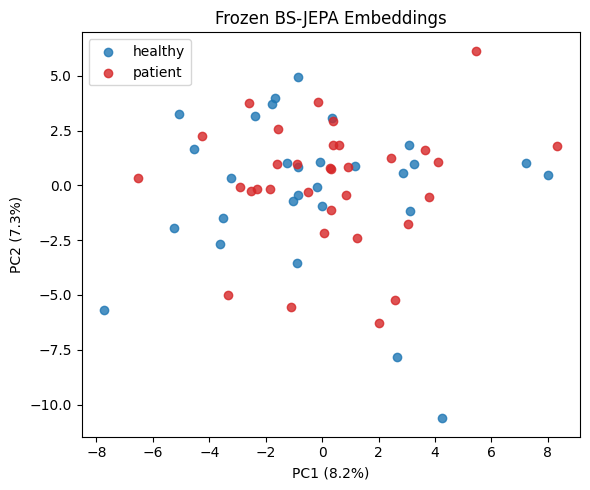

In [53]:
model.eval()
with torch.no_grad():
    embeddings_tensor, embedding_subject_ids = extract_subject_embeddings(
        model,
        labeled_graph_dataset,
        device=DEVICE,
        batch_size=BATCH_SIZE,
    )

X_bsjepa = embeddings_tensor.detach().cpu().numpy().astype(np.float32)
y = np.asarray(labels, dtype=int)
subject_ids = list(embedding_subject_ids)

if not np.isfinite(X_bsjepa).all():
    raise ValueError("BS-JEPA embeddings contain NaN or inf values")
if X_bsjepa.shape[0] != len(y):
    raise ValueError("Embedding rows do not align with labels")

print(f"X_bsjepa_shape={X_bsjepa.shape}")
print(f"y_counts={dict(Counter(y))}")
print(f"embedding_variance_mean={float(X_bsjepa.var(axis=0).mean()):.6g}")
print(f"embedding_variance_min={float(X_bsjepa.var(axis=0).min()):.6g}")
print(f"embedding_variance_max={float(X_bsjepa.var(axis=0).max()):.6g}")

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(StandardScaler().fit_transform(X_bsjepa))
fig, ax = plt.subplots(figsize=(6, 5))
for label, name, color in [(0, "healthy", "tab:blue"), (1, "patient", "tab:red")]:
    mask = y == label
    ax.scatter(coords[mask, 0], coords[mask, 1], label=name, alpha=0.8, color=color)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Frozen BS-JEPA Embeddings")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bsjepa_embedding_pca.png", dpi=160)
plt.show()

## Raw Baseline Feature Extraction

Raw baselines use the same subjects and labels as the BS-JEPA embeddings. The primary raw baseline is the graph adjacency/FC upper triangle. If raw dimensionality is high relative to sample size, PCA is added inside sklearn pipelines so it is fit only on training folds.

In [54]:
def graph_to_dense_adjacency(graph: Data) -> torch.Tensor:
    node_count = int(graph.num_nodes)
    adjacency = torch.zeros(node_count, node_count, dtype=torch.float32)
    values = graph.edge_attr.detach().cpu().float().view(-1) if graph.edge_attr is not None else torch.ones(graph.edge_index.shape[1])
    edge_index = graph.edge_index.detach().cpu()
    adjacency[edge_index[0], edge_index[1]] = values
    # Symmetrize defensively for upper-triangle feature extraction.
    adjacency = torch.maximum(adjacency, adjacency.T)
    return adjacency


def extract_upper_triangle_adjacency_features(graphs: list[Data]) -> np.ndarray:
    if not graphs:
        raise ValueError("No graphs provided")
    node_count = int(graphs[0].num_nodes)
    if any(int(graph.num_nodes) != node_count for graph in graphs):
        raise ValueError("All graphs must have the same number of nodes")
    row, col = torch.triu_indices(node_count, node_count, offset=1)
    features = []
    for graph in graphs:
        adjacency = graph_to_dense_adjacency(graph)
        features.append(adjacency[row, col].numpy())
    return np.stack(features).astype(np.float32)

X_raw_fc = extract_upper_triangle_adjacency_features(graphs)
if not np.isfinite(X_raw_fc).all():
    raise ValueError("Raw FC features contain NaN or inf values")
print(f"X_raw_fc_shape={X_raw_fc.shape}")
print(f"raw_feature_to_sample_ratio={X_raw_fc.shape[1] / X_raw_fc.shape[0]:.1f}")

np.savez_compressed(
    OUTPUT_DIR / "features_and_labels.npz",
    X_bsjepa=X_bsjepa,
    X_raw_fc=X_raw_fc,
    y=y,
    subject_ids=np.asarray(subject_ids),
)

X_raw_fc_shape=(62, 71631)
raw_feature_to_sample_ratio=1155.3


## Classifiers and Evaluation Protocol

Models are compared with identical stratified folds. Primary metric is balanced accuracy. Secondary metrics are accuracy, F1, ROC-AUC, patient sensitivity, and healthy specificity.

In [56]:
def should_use_raw_pca(X: np.ndarray) -> bool:
    if USE_RAW_PCA == "auto":
        return X.shape[1] > max(50, 5 * X.shape[0])
    return bool(USE_RAW_PCA)


def scaled_classifier_pipeline(estimator, *, use_pca: bool = False) -> Pipeline:
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=RAW_PCA_VARIANCE, svd_solver="full", random_state=RANDOM_SEED)))
    steps.append(("classifier", estimator))
    return Pipeline(steps)


def make_classifiers(feature_set: str, X: np.ndarray) -> dict[str, Any]:
    use_pca = feature_set == "raw_fc" and should_use_raw_pca(X)
    return {
        "Dummy majority": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": scaled_classifier_pipeline(
            LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
            use_pca=use_pca,
        ),
        "Linear SVM": scaled_classifier_pipeline(
            SVC(kernel="linear", class_weight="balanced", probability=True, random_state=RANDOM_SEED),
            use_pca=use_pca,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
    }


def score_estimator(estimator, X_test: np.ndarray, y_test: np.ndarray) -> tuple[np.ndarray, np.ndarray | None]:
    y_pred = estimator.predict(X_test)
    score = None
    if hasattr(estimator, "predict_proba"):
        prob = estimator.predict_proba(X_test)
        if prob.shape[1] == 2:
            score = prob[:, 1]
    elif hasattr(estimator, "decision_function"):
        score = estimator.decision_function(X_test)
    return y_pred, score


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, score: np.ndarray | None) -> dict[str, float]:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "sensitivity_patient": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity_healthy": tn / (tn + fp) if (tn + fp) else np.nan,
        "roc_auc": np.nan,
    }
    if score is not None and len(np.unique(y_true)) == 2:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, score)
        except ValueError:
            metrics["roc_auc"] = np.nan
    return metrics


def cross_validate_feature_set(feature_set: str, X: np.ndarray, y: np.ndarray, splits: list[tuple[np.ndarray, np.ndarray]]) -> pd.DataFrame:
    rows = []
    classifiers = make_classifiers(feature_set, X)
    for fold, (train_idx, val_idx) in enumerate(splits, start=1):
        for model_name, estimator in classifiers.items():
            fitted = clone(estimator)
            fitted.fit(X[train_idx], y[train_idx])
            y_pred, score = score_estimator(fitted, X[val_idx], y[val_idx])
            rows.append({
                "feature_set": feature_set,
                "model": model_name,
                "fold": fold,
                **compute_metrics(y[val_idx], y_pred, score),
            })
    return pd.DataFrame(rows)

min_class_count = min(Counter(y).values())
if min_class_count < 2:
    raise ValueError("Each class needs at least two subjects for stratified evaluation")
effective_splits = min(N_SPLITS, min_class_count)
if effective_splits < N_SPLITS:
    warnings.warn(f"Reducing N_SPLITS from {N_SPLITS} to {effective_splits} because of class counts")

skf = StratifiedKFold(n_splits=effective_splits, shuffle=True, random_state=RANDOM_SEED)
splits = list(skf.split(X_bsjepa, y))

feature_sets = {
    "bsjepa_embedding": X_bsjepa,
    "raw_fc": X_raw_fc,
}

results_per_fold = pd.concat(
    [cross_validate_feature_set(name, X, y, splits) for name, X in feature_sets.items()],
    ignore_index=True,
)

summary = (
    results_per_fold
    .groupby(["feature_set", "model"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        sensitivity_patient_mean=("sensitivity_patient", "mean"),
        specificity_healthy_mean=("specificity_healthy", "mean"),
    )
    .sort_values("balanced_accuracy_mean", ascending=False)
)

results_per_fold.to_csv(OUTPUT_DIR / "results_per_fold.csv", index=False)
summary.to_csv(OUTPUT_DIR / "results_summary.csv", index=False)

display(summary)

,feature_set,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,sensitivity_patient_mean,specificity_healthy_mean
7,raw_fc,Random Forest,0.775641,0.102564,0.770476,0.097439,0.782857,0.101776,0.795873,0.180996,0.780952,0.760000
6,raw_fc,Logistic Regression,0.646154,0.126868,0.641429,0.135355,0.626025,0.148980,0.791746,0.112404,0.576190,0.706667
5,raw_fc,Linear SVM,0.583333,0.170023,0.581905,0.166144,0.503601,0.288169,0.528730,0.311706,0.457143,0.706667
0,bsjepa_embedding,Dummy majority,0.532051,0.034520,0.500000,0.000000,0.694035,0.029162,0.500000,0.000000,1.000000,0.000000
4,raw_fc,Dummy majority,0.532051,0.034520,0.500000,0.000000,0.694035,0.029162,0.500000,0.000000,1.000000,0.000000
1,bsjepa_embedding,Linear SVM,0.497436,0.156599,0.491429,0.160026,0.506667,0.197191,0.475238,0.231342,0.509524,0.473333
2,bsjepa_embedding,Logistic Regression,0.497436,0.156599,0.491429,0.160026,0.506667,0.197191,0.434603,0.191513,0.509524,0.473333
3,bsjepa_embedding,Random Forest,0.462821,0.185588,0.454762,0.192032,0.564043,0.161650,0.506825,0.176607,0.676190,0.233333


## Held-Out Test Split

The held-out split is used for concrete classification reports, confusion matrices, and ROC plots after model selection from cross-validation summaries.

In [57]:
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)

best_bsjepa_row = summary[summary["feature_set"] == "bsjepa_embedding"].iloc[0]
best_raw_row = summary[summary["feature_set"] == "raw_fc"].iloc[0]

heldout_models = {
    "best_bsjepa": ("bsjepa_embedding", best_bsjepa_row["model"], X_bsjepa),
    "best_raw_fc": ("raw_fc", best_raw_row["model"], X_raw_fc),
}

heldout_results = {}
for label, (feature_set, model_name, X) in heldout_models.items():
    estimator = make_classifiers(feature_set, X)[model_name]
    estimator.fit(X[train_idx], y[train_idx])
    y_pred, score = score_estimator(estimator, X[test_idx], y[test_idx])
    heldout_results[label] = {
        "feature_set": feature_set,
        "model": model_name,
        "estimator": estimator,
        "y_true": y[test_idx],
        "y_pred": y_pred,
        "score": score,
        "metrics": compute_metrics(y[test_idx], y_pred, score),
    }
    print("\n====", label, feature_set, model_name)
    print(heldout_results[label]["metrics"])
    print(classification_report(y[test_idx], y_pred, target_names=["healthy", "patient"], zero_division=0))

pd.DataFrame([
    {"comparison": key, "feature_set": value["feature_set"], "model": value["model"], **value["metrics"]}
    for key, value in heldout_results.items()
]).to_csv(OUTPUT_DIR / "heldout_test_results.csv", index=False)


==== best_bsjepa bsjepa_embedding Dummy majority
{'accuracy': 0.5384615384615384, 'balanced_accuracy': 0.5, 'f1': 0.7, 'sensitivity_patient': np.float64(1.0), 'specificity_healthy': np.float64(0.0), 'roc_auc': 0.5}
              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00         6
     patient       0.54      1.00      0.70         7

    accuracy                           0.54        13
   macro avg       0.27      0.50      0.35        13
weighted avg       0.29      0.54      0.38        13


==== best_raw_fc raw_fc Random Forest
{'accuracy': 0.9230769230769231, 'balanced_accuracy': 0.9285714285714286, 'f1': 0.9230769230769231, 'sensitivity_patient': np.float64(0.8571428571428571), 'specificity_healthy': np.float64(1.0), 'roc_auc': 0.8809523809523809}
              precision    recall  f1-score   support

     healthy       0.86      1.00      0.92         6
     patient       1.00      0.86      0.92         7

    accuracy                

## Results Tables and Plots

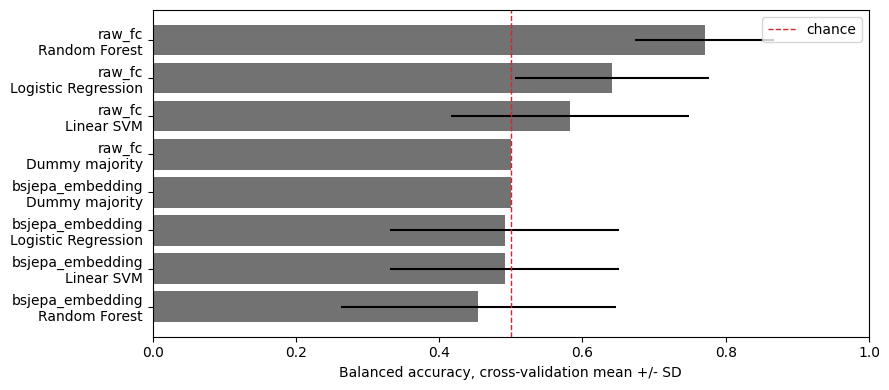

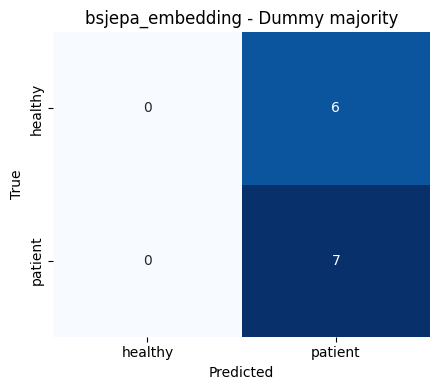

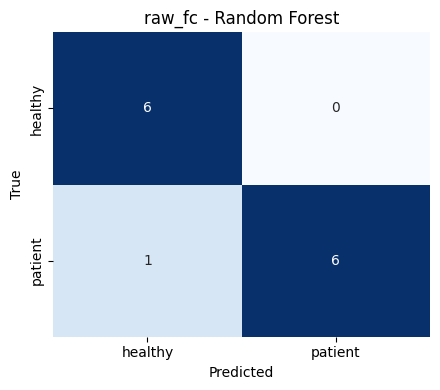

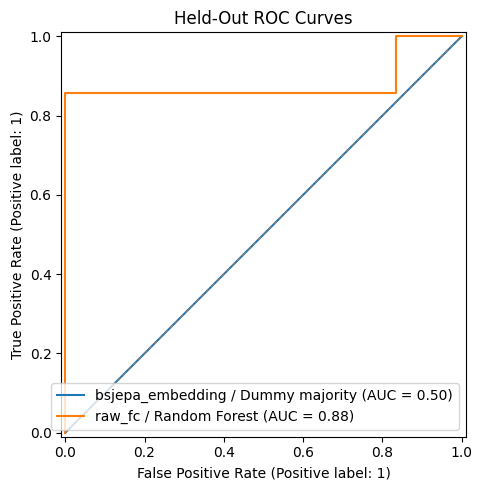

Saved results and plots to /Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Code/bs_jepa/outputs/patient_vs_healthy_evaluation


In [58]:
plot_df = summary.copy()
plot_df["label"] = plot_df["feature_set"] + "\n" + plot_df["model"]
plot_df = plot_df.sort_values("balanced_accuracy_mean", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
ax.barh(
    plot_df["label"],
    plot_df["balanced_accuracy_mean"],
    xerr=plot_df["balanced_accuracy_std"].fillna(0),
    color="0.35",
    alpha=0.85,
)
ax.axvline(0.5, color="tab:red", linestyle="--", linewidth=1, label="chance")
ax.set_xlabel("Balanced accuracy, cross-validation mean +/- SD")
ax.set_xlim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "balanced_accuracy_barplot.png", dpi=180)
plt.show()


def plot_confusion(result_key: str, filename: str) -> None:
    result = heldout_results[result_key]
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    if HAS_SEABORN:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["healthy", "patient"], yticklabels=["healthy", "patient"], ax=ax)
    else:
        im = ax.imshow(cm, cmap="Blues")
        for (i, j), value in np.ndenumerate(cm):
            ax.text(j, i, str(value), ha="center", va="center")
        ax.set_xticks([0, 1], ["healthy", "patient"])
        ax.set_yticks([0, 1], ["healthy", "patient"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{result['feature_set']} - {result['model']}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

plot_confusion("best_bsjepa", "confusion_best_bsjepa.png")
plot_confusion("best_raw_fc", "confusion_best_raw_fc.png")

fig, ax = plt.subplots(figsize=(6, 5))
for key, result in heldout_results.items():
    if result["score"] is None or len(np.unique(result["y_true"])) != 2:
        continue
    RocCurveDisplay.from_predictions(
        result["y_true"],
        result["score"],
        name=f"{result['feature_set']} / {result['model']}",
        ax=ax,
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="0.5", linewidth=1)
ax.set_title("Held-Out ROC Curves")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heldout_roc_curves.png", dpi=180)
plt.show()

print(f"Saved results and plots to {OUTPUT_DIR}")

## Optional Permutation-Label Sanity Check

This checks whether performance collapses toward chance when labels are shuffled. It is intentionally small and optional.

In [59]:
RUN_PERMUTATION_CHECK = False

if RUN_PERMUTATION_CHECK:
    rng = np.random.default_rng(RANDOM_SEED)
    y_perm = rng.permutation(y)
    perm_rows = []
    for feature_set, X in {"bsjepa_embedding": X_bsjepa, "raw_fc": X_raw_fc}.items():
        model_name = "Logistic Regression"
        estimator = make_classifiers(feature_set, X)[model_name]
        for fold, (tr, va) in enumerate(splits, start=1):
            fitted = clone(estimator)
            fitted.fit(X[tr], y_perm[tr])
            y_pred, score = score_estimator(fitted, X[va], y_perm[va])
            perm_rows.append({"feature_set": feature_set, "model": model_name, "fold": fold, **compute_metrics(y_perm[va], y_pred, score)})
    permutation_results = pd.DataFrame(perm_rows)
    display(permutation_results.groupby(["feature_set", "model"])["balanced_accuracy"].agg(["mean", "std"]))
else:
    print("Set RUN_PERMUTATION_CHECK = True to run this optional sanity check.")

Set RUN_PERMUTATION_CHECK = True to run this optional sanity check.


## Interpretation

The statements below summarize predictive performance only. They should not be interpreted as clinical validation or a diagnostic claim.

In [ ]:
best_bsjepa = summary[summary["feature_set"] == "bsjepa_embedding"].iloc[0]
best_raw = summary[summary["feature_set"] == "raw_fc"].iloc[0]
delta = best_bsjepa["balanced_accuracy_mean"] - best_raw["balanced_accuracy_mean"]

print("Best frozen BS-JEPA embedding classifier:")
print(best_bsjepa[["model", "balanced_accuracy_mean", "balanced_accuracy_std", "roc_auc_mean", "f1_mean"]].to_string())
print("\nBest raw FC baseline classifier:")
print(best_raw[["model", "balanced_accuracy_mean", "balanced_accuracy_std", "roc_auc_mean", "f1_mean"]].to_string())
print(f"\nBalanced accuracy difference, BS-JEPA minus raw baseline: {delta:.3f}")

if delta > 0:
    print("Preliminary result: the frozen BS-JEPA representation outperformed the best raw FC baseline on mean CV balanced accuracy.")
elif delta < 0:
    print("Preliminary result: the best raw FC baseline outperformed the frozen BS-JEPA representation on mean CV balanced accuracy.")
else:
    print("Preliminary result: frozen BS-JEPA and raw FC tied on mean CV balanced accuracy.")

print("\nCaveats: sample size, class imbalance, site/scanner effects, motion, age, sex, and preprocessing differences can all affect results. Treat this as preliminary model comparison, not clinical evidence.")

## Optional Extension: Fine-Tuning

Fine-tuning the BS-JEPA encoder is not part of the main evaluation because it increases leakage and overfitting risk on small clinical datasets. If you later fine-tune, do it strictly inside each training fold with a held-out validation strategy, never on the full dataset before cross-validation.

## Run Checklist

Expected run order and outputs:

1. Run **Imports and Configuration**. Confirm `DATA_DIR`, `ARTIFACT_OR_CHECKPOINT_PATH`, `ATLAS_CSV`, and label mapping.
2. Run **Dataset Inspection**. For this dataset you should see `moodlearning_merged.pkl`, `moodlearning_pz.pkl`, and `moodlearning_cont.pkl`.
3. Run **Dataset Loading Helpers** and the loading cell. Expected current labels: `pz = patient`, `nc = healthy`.
4. Run **Atlas and Graph Construction**. If atlas inference fails, set `ATLAS_CSV` manually to the same Glasser-379 RSN mapping used in pretraining.
5. Run **Pretrained Model Loading**. If no artifact is found, set `ARTIFACT_OR_CHECKPOINT_PATH` to your exported `*_final.pt`, artifact directory, or checkpoint.
6. Run embedding extraction, baseline extraction, evaluation, plots, and interpretation.

The notebook saves outputs to `outputs/patient_vs_healthy_evaluation/`:

- `results_per_fold.csv`
- `results_summary.csv`
- `heldout_test_results.csv`
- `features_and_labels.npz`
- `bsjepa_embedding_pca.png`
- `balanced_accuracy_barplot.png`
- confusion matrix and ROC plots